
## NC Analysis

### Objective: Analyze all sensor Gen 3 NC records logged in Salesforce since product launch to classify and rank failure modes ("problem flags") and root causes. Use this categorisation and ranking to inform the value and design requirements of developing the next generation sensor.

#### Key Findings
- Unintended Activation accounts for 70% of NC's. They are the dominant failure mode.
- Within Unintended Activation 38% of cases have no determined root cause. The largest known cause is early Shipping Lock removal.
- Leaking is driven almost entirely (73%) by Rolling Seal failure.

### 1. Setup
#### Imports

In [28]:
# Standard library
import sys
from pathlib import Path

# Data handling
import pandas as pd

# Plotting
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+png"

# Local modules
sys.path.append("..") 
from src.data_io import load_nc_data, load_sales_data
from src.aggregate import get_counts_with_labels, build_quarterly_counts, format_quarter, share_of, leader
from src.plotting import (
    ACCENT, NEUTRAL, CONTEXT, GRID, GREY_RAMP_LONG, add_source, export_charts,build_emphasis_map, ranked_bar
)

In [29]:
FIGURES = Path("..") / "reports" / "figures"

### 2. Load and clean data

Load the NC and sales data.

 - The NC data was exported from Salesforce then cleaned and labeled. The labelling process included reading the NC reports / email attachments or whatever information was available for the case.

- The sales data was provided by the operations team. The monthly grand total sales were extracted into a CSV for analysis.

In [30]:
df = load_nc_data("../data/NC-raw-data-extra-filtered.csv")
df_sales = load_sales_data("../data/Sales-data.csv")

### 3. Feature Engineering / Subsetting

In [31]:
#Analyse "Engineering - Customer" cases only
df_customer = df[df["Department"] == "Engineering - Customer"].copy()
df_customer["Department"].unique()


#Engineering - Customer Problem Flag Counts
df_customer["Problem Flag"].value_counts()
pflag_counts = get_counts_with_labels(df_customer, "Problem Flag")


#Engineering - Customer Root Cause Counts
rootcause_counts = get_counts_with_labels(df_customer, "Root Cause") 
df_rootcause_filtered = df_customer[~df_customer["Root Cause"].isin(["Undetermined", "Other"])]
rootcause_known_counts = get_counts_with_labels(df_rootcause_filtered, "Root Cause")

#Unintended Activations 
df_ua = df_customer[df_customer["Problem Flag"] == "Unintended Activation"].copy()
ua_counts = get_counts_with_labels(df_ua, "Root Cause")

df_ua_known = df_ua[df_ua["Root Cause"] != "Undetermined"]
ua_known_counts = get_counts_with_labels(df_ua_known, "Root Cause")

#Leaking
df_leak = df_customer[df_customer["Problem Flag"] == "Leaking"].copy()
leak_counts = get_counts_with_labels(df_leak, "Root Cause")

#Utility Cases
df_utility = df_customer[df_customer["Case Origin"] == "Utility"].copy()
utility_counts = df_utility["Account Name"].value_counts().reset_index()
utility_counts.columns = ["Account Name", "Count"]

# Top 10 hardest hit utilities
utility_top10 = utility_counts.head(10).copy()
utility_top10["Label"] = utility_top10["Count"].astype(str)

#TM Cases
df_tm = df_customer[df_customer["Case Origin"] == "Transformer Manufacturer"].copy()
tm_counts = df_tm["Account Name"].value_counts().reset_index()
tm_counts.columns = ["Account Name", "Count"]

# Top 10 hardest hit TM's
tm_top10 = tm_counts.head(10).copy()
tm_top10["Label"] = tm_top10["Count"].astype(str)



#### Unintended Activations: Quarterly Analysis

Initally we will calculate number of NC's opened per 10k units sold.

In [32]:
#NC's per quarter
nc_quarterly = df_customer.groupby('quarter').size().rename('nc_count')

#Sales by quarter
sales_quarterly = df_sales.groupby('quarter')['unit_sensors_sold'].sum()

combined = pd.merge(nc_quarterly, sales_quarterly, left_index=True, right_index=True, how='right')
combined['nc_per_10k'] = combined['nc_count'] / combined['unit_sensors_sold'] * 10_000
combined = combined.reset_index().rename(columns={'quarter': 'Quarter', 'nc_per_10k': 'NC per 10k'})

combined['Quarter'] = combined['Quarter'].astype(str)

quarter_order = sorted(combined["Quarter"].unique())
quarter_order = [format_quarter(q) for q in quarter_order]
combined["Quarter"] = combined["Quarter"].map(format_quarter)

# lock in chronological order for the line chart (go.Scatter has no category_orders)
combined['Quarter'] = pd.Categorical(combined['Quarter'], categories=quarter_order, ordered=True)
combined = combined.sort_values('Quarter')

Problem Flag Quarterly Analysis

Use this to identify changes in Unintended Activations Root Causes over time.

In [33]:
#Problem Flag
quarterly_pflag_counts = build_quarterly_counts(df_customer, "Problem Flag") #Group cases into financial quarter
quarter_order = sorted(df["quarter"].unique())
quarter_order = [format_quarter(q) for q in quarter_order]

#Unintended Activations - Grouping non top 6 Root causes
keep_causes = [
    "Undetermined",
    "SL removed before install",
    "Venting under vaccuum",
    "Incorrect SL Install",
    "Activated on TM Line",
    "1-ph pad lid closing"
]

df_ua["Root Cause Grouped"] = df_ua["Root Cause"].where(df_ua["Root Cause"].isin(keep_causes), "Other")
quarterly_ua_grouped_counts = build_quarterly_counts(df_ua, "Root Cause Grouped")


### 4. Analysis / Visualization

#### Problem Flag Analysis
Breakdown of NC's by Problem Flag across all Engineering - Customer cases

In [34]:
print(pflag_counts)

            Problem Flag  Count  Percent        Label
0  Unintended Activation    234     70.3  234 (70.3%)
1                  Other     59     17.7   59 (17.7%)
2                Leaking     37     11.1   37 (11.1%)
3   Energized Activation      2      0.6     2 (0.6%)
4       Did not Activate      1      0.3     1 (0.3%)


Generate bar chart of NC's by Problem Flag

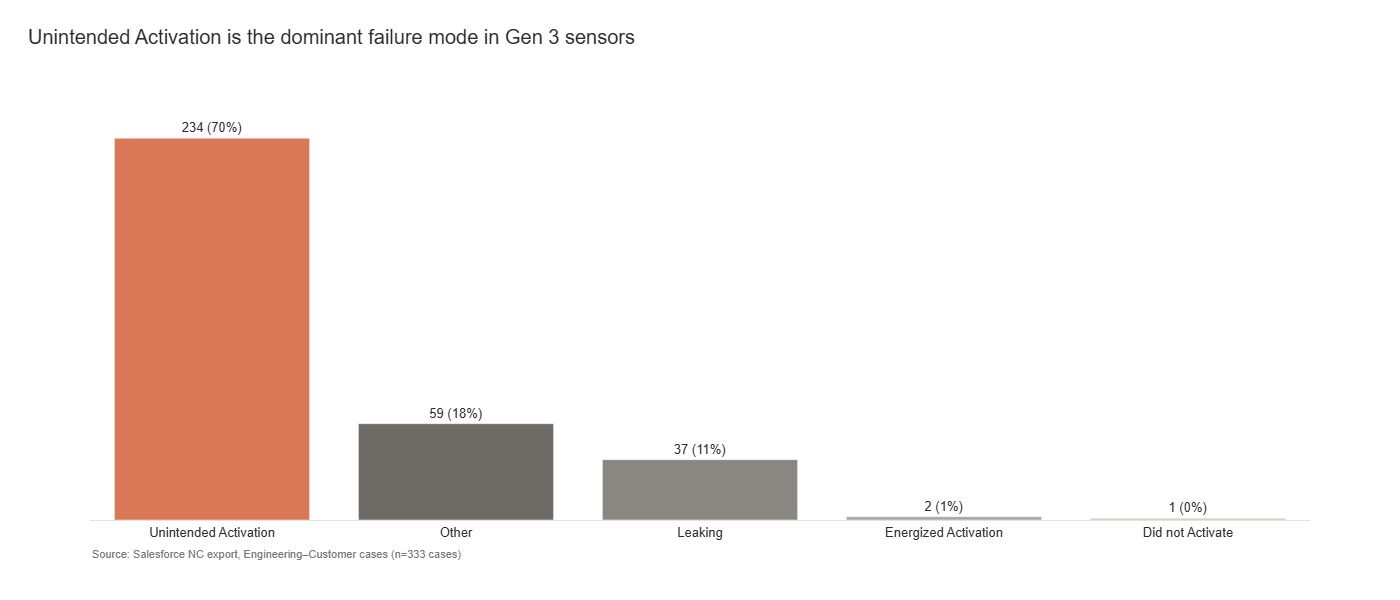

In [35]:
top_flag = leader(pflag_counts, "Problem Flag")
pflag_color_map = build_emphasis_map(pflag_counts["Problem Flag"], top_flag)
pflag_marker_colors = [pflag_color_map[f] for f in pflag_counts["Problem Flag"]]

pflag_counts = pflag_counts.copy()
pct = pflag_counts["Count"] / pflag_counts["Count"].sum() * 100
pflag_counts["_label"] = [f"{v:,.0f} ({p:.0f}%)"
                          for v, p in zip(pflag_counts["Count"], pct)]

fig_pflag_bar = px.bar(
    pflag_counts, x="Problem Flag", y="Count", text="_label",
    color="Problem Flag", color_discrete_map=pflag_color_map,
    title=f"{top_flag} is the dominant failure mode in Gen 3 sensors",
)
fig_pflag_bar.update_traces(textposition="outside")
fig_pflag_bar.update_xaxes(title="")
fig_pflag_bar.update_yaxes(
    showticklabels=False, showgrid=False, title="",
    range=[0, pflag_counts["Count"].max() * 1.1],
)
fig_pflag_bar.update_layout(showlegend=False)
add_source(fig_pflag_bar, f"Source: Salesforce NC export, Engineering–Customer cases (n={len(df_customer)} cases)")

Generate pie chart of proportion of NC's by Problem Flag

In [36]:
top_flag_pct = share_of(pflag_counts, "Problem Flag", top_flag)

fig_pflag_pie = px.pie(
    pflag_counts,
    names="Problem Flag", values="Count",
    color="Problem Flag", color_discrete_map=pflag_color_map,
    title=f"{top_flag} accounts for {top_flag_pct:.0f}% of Gen 3 NCs",
)
fig_pflag_pie.update_traces(
    texttemplate="%{label}<br>%{percent:.0%}",
    insidetextorientation="horizontal",
)
fig_pflag_pie.update_layout(showlegend=False)
add_source(fig_pflag_pie, f"Source: Salesforce NC export, Engineering–Customer cases (n={len(df_customer)} cases)"); #Pie chart suppresed here but exported for stakeholder presentation

#### Root Cause Analysis (All)
Root Cause breakdown across all Engineering - Customer cases including Undetermined

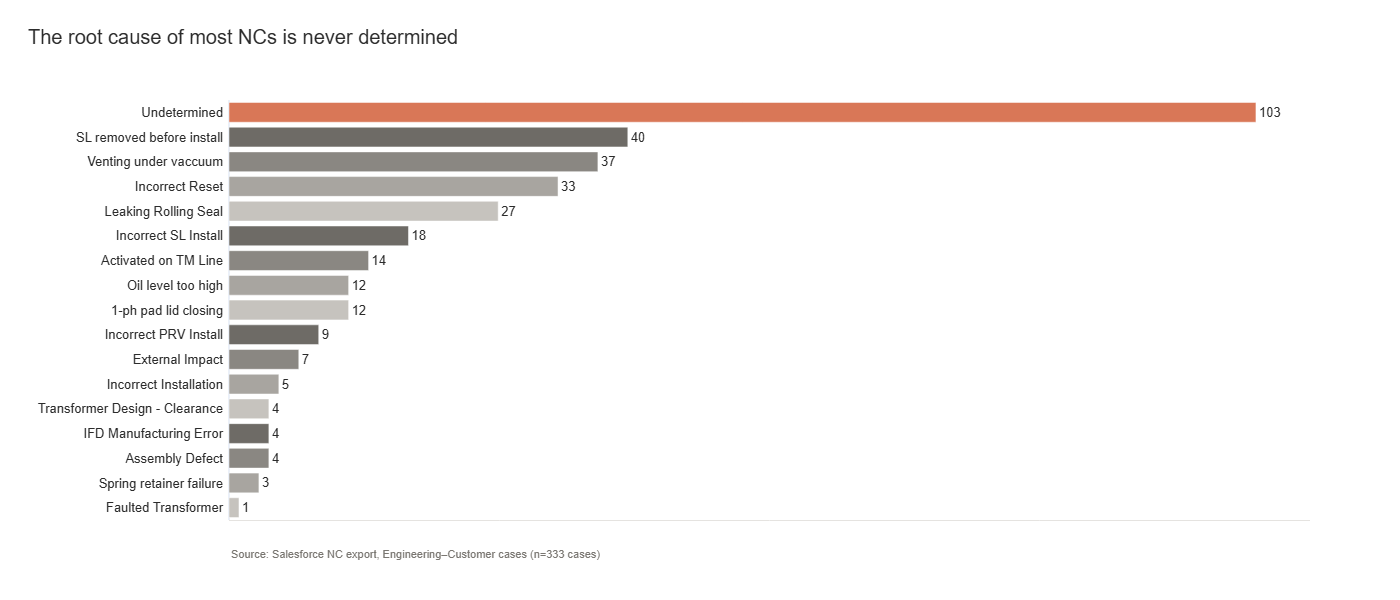

In [37]:
fig_rootcause_bar = ranked_bar(
    rootcause_counts, "Root Cause", "Undetermined",
    "The root cause of most NCs is never determined",
)
add_source(fig_rootcause_bar, "Source: Salesforce NC export, Engineering–Customer cases (n=333 cases)")
fig_rootcause_bar.show()


Same breakdown excluding Undetermined and Other - shows what we actually know

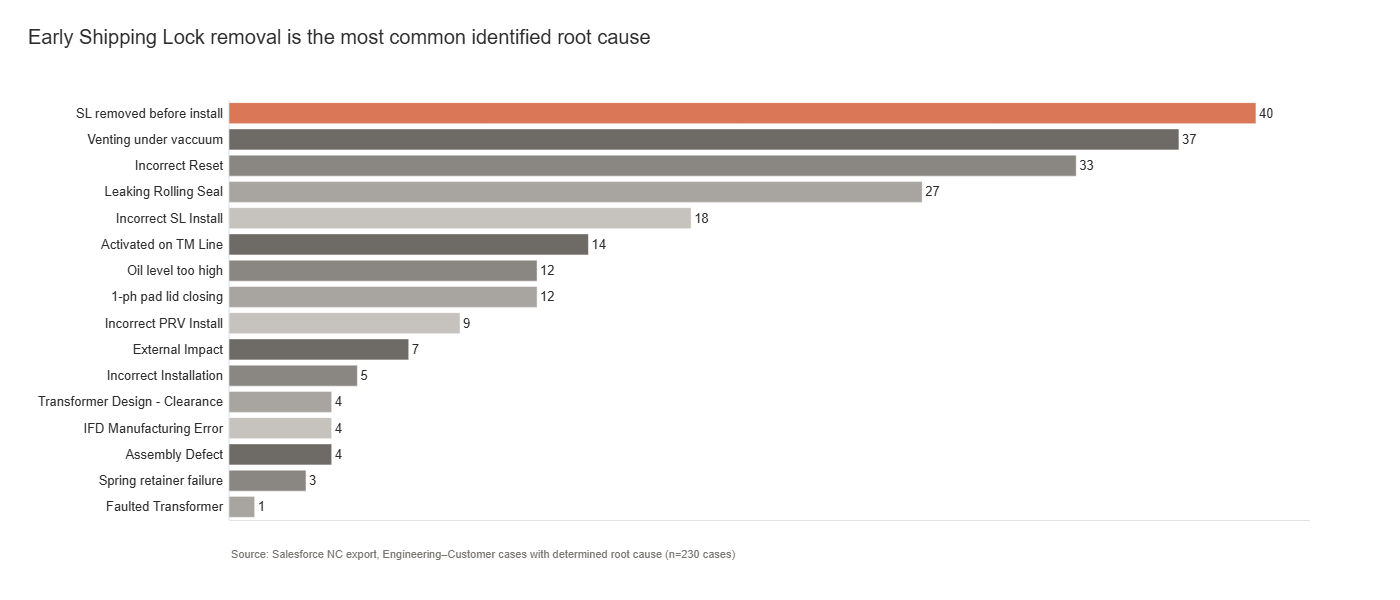

In [38]:
fig_rootcause_known_bar = ranked_bar(
    rootcause_known_counts, "Root Cause", "SL removed before install",
    "Early Shipping Lock removal is the most common identified root cause",
)
add_source(fig_rootcause_known_bar, f"Source: Salesforce NC export, Engineering–Customer cases with determined root cause (n={len(df_rootcause_filtered)} cases)")
fig_rootcause_known_bar.show()


#### Unintended Activation - Root Cause Breakdown
Isolate Unintended Activation cases and look at Root Cause within just this problem flag

In [39]:
print(ua_counts)

                        Root Cause  Count  Percent       Label
0                     Undetermined     90     38.5  90 (38.5%)
1        SL removed before install     40     17.1  40 (17.1%)
2            Venting under vaccuum     37     15.8  37 (15.8%)
3             Incorrect SL Install     18      7.7   18 (7.7%)
4             Activated on TM Line     14      6.0   14 (6.0%)
5             1-ph pad lid closing     12      5.1   12 (5.1%)
6            Incorrect PRV Install      8      3.4    8 (3.4%)
7               Oil level too high      5      2.1    5 (2.1%)
8   Transformer Design - Clearance      4      1.7    4 (1.7%)
9                  External Impact      3      1.3    3 (1.3%)
10                 Assembly Defect      1      0.4    1 (0.4%)
11          Incorrect Installation      1      0.4    1 (0.4%)
12             Faulted Transformer      1      0.4    1 (0.4%)


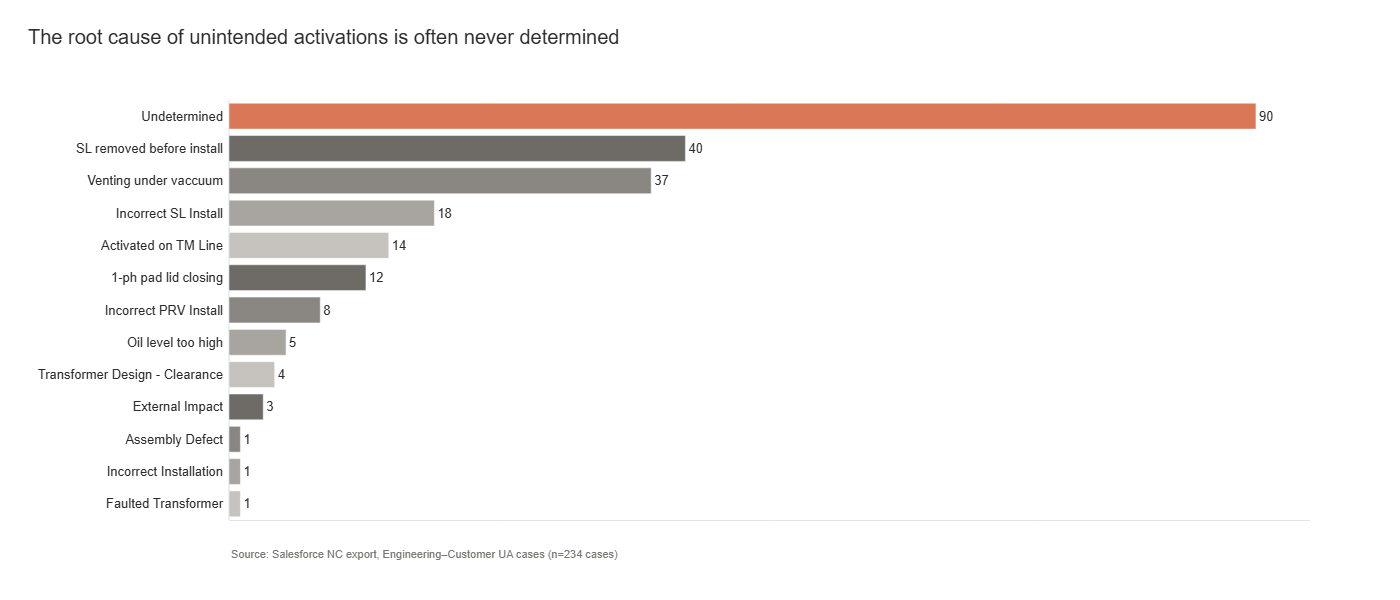

In [40]:
fig_ua_bar = ranked_bar(ua_counts, "Root Cause", "Undetermined",
                        "The root cause of unintended activations is often never determined")
add_source(fig_ua_bar, f"Source: Salesforce NC export, Engineering–Customer UA cases (n={len(df_ua)} cases)")
fig_ua_bar.show()

In [41]:
ua_known_color_map = build_emphasis_map(ua_known_counts["Root Cause"], "SL removed before install")

fig_ua_known_pie = px.pie(
    ua_known_counts,
    names="Root Cause", values="Count",
    color="Root Cause", color_discrete_map=ua_known_color_map,
    title="Unintended activations come from a variety of root causes",
)
fig_ua_known_pie.update_traces(
    texttemplate="%{label}<br>%{percent:.0%}",
    insidetextorientation="horizontal",
)
fig_ua_known_pie.update_layout(showlegend=False)
add_source(fig_ua_known_pie, f"Source: Salesforce NC export, Engineering–Customer UA cases with determined root cause (n={len(df_ua_known)} cases)", y=-0.22)
fig_ua_known_pie.update_layout(margin=dict(b=90)); #Pie chart suppresed here but exported for stakeholder presentation

#### Leaking - Root Cause Breakdown
Same drill-down for Leaking cases

In [42]:
print(leak_counts)

             Root Cause  Count  Percent       Label
0  Leaking Rolling Seal     27     73.0  27 (73.0%)
1          Undetermined      5     13.5   5 (13.5%)
2    Oil level too high      3      8.1    3 (8.1%)
3       Assembly Defect      2      5.4    2 (5.4%)


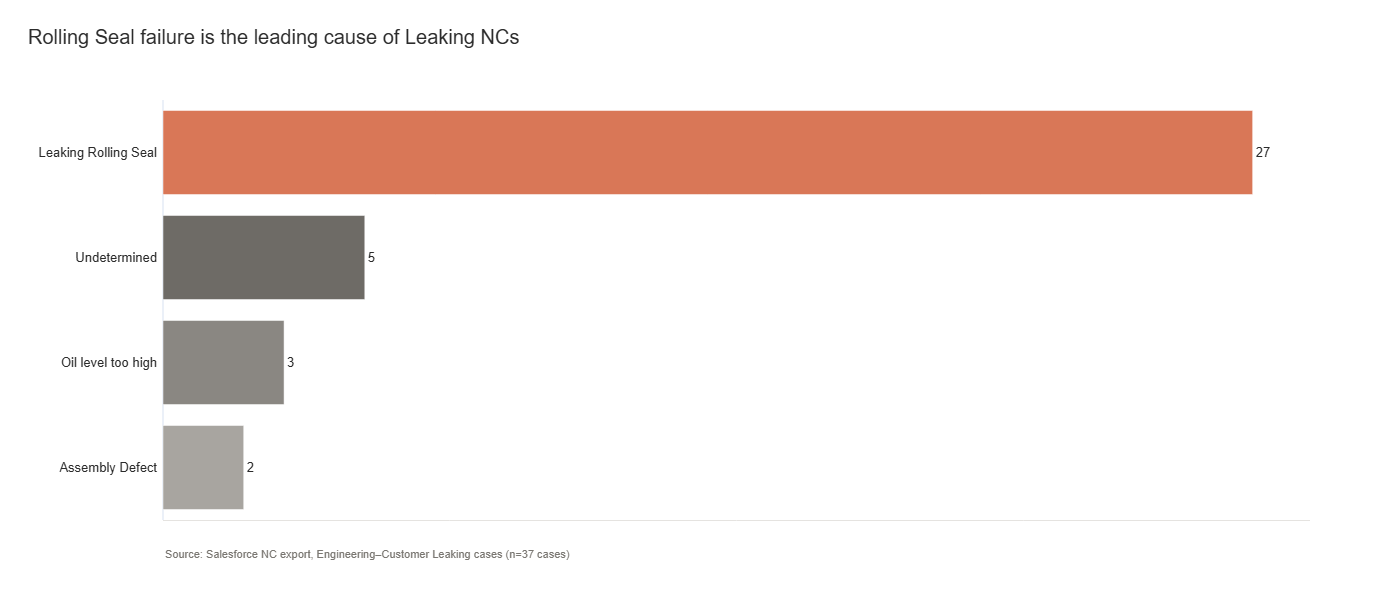

In [43]:
top_leak_cause = leader(leak_counts, "Root Cause")

fig_leak_bar = ranked_bar(
    leak_counts, "Root Cause", top_leak_cause,
    "Rolling Seal failure is the leading cause of Leaking NCs",
)
add_source(fig_leak_bar, f"Source: Salesforce NC export, Engineering–Customer Leaking cases (n={len(df_leak)} cases)")

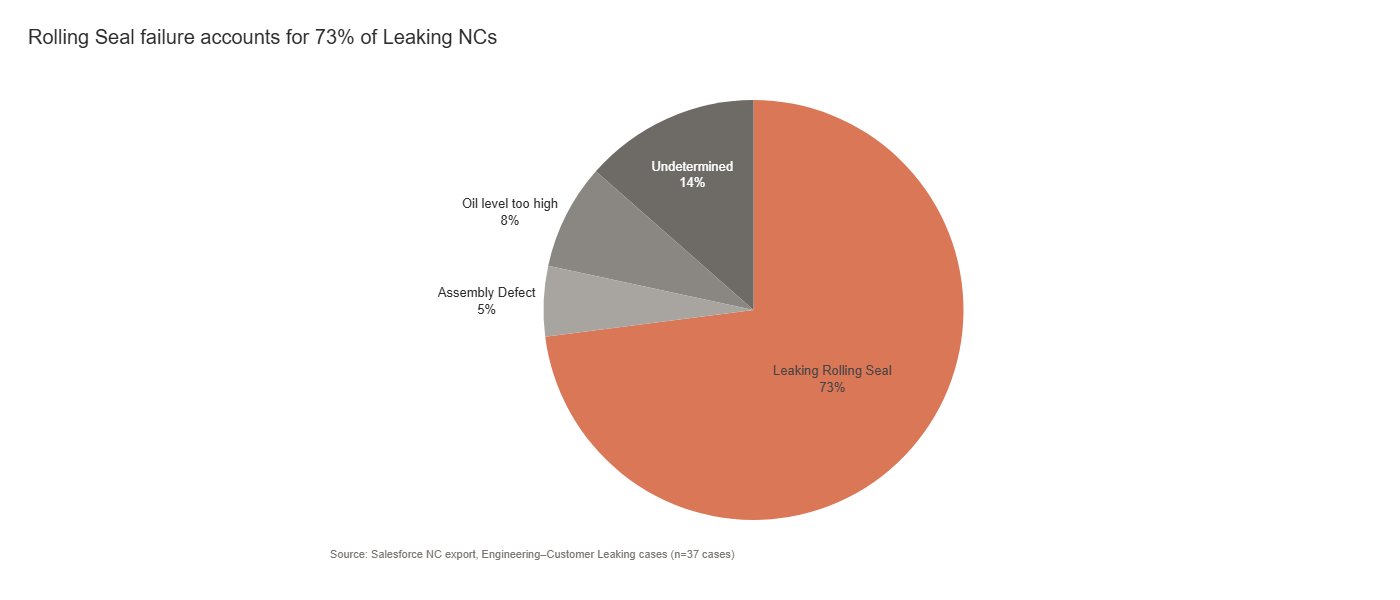

In [44]:
leak_color_map = build_emphasis_map(leak_counts["Root Cause"], top_leak_cause)
top_leak_pct = share_of(leak_counts, "Root Cause", top_leak_cause)

fig_leak_pie = px.pie(
    leak_counts,
    names="Root Cause", values="Count",
    color="Root Cause", color_discrete_map=leak_color_map,
    title=f"Rolling Seal failure accounts for {top_leak_pct:.0f}% of Leaking NCs",
)
fig_leak_pie.update_traces(
    texttemplate="%{label}<br>%{percent:.0%}",
    insidetextorientation="horizontal",
)
fig_leak_pie.update_layout(showlegend=False)
add_source(fig_leak_pie, f"Source: Salesforce NC export, Engineering–Customer Leaking cases (n={len(df_leak)} cases)")

#### Account Analysis
Start by splitting into Root Cause Origin Utility vs TM
From there keep the top 10 by number of NC's and group the rest into Other

In [45]:
print(utility_top10)

                            Account Name  Count Label
0     Pacific Gas and Electric Co [PG&E]     11    11
1              Pedernales Electric [PEC]      7     7
2            Montana-Dakota Utilities Co      7     7
3                          Hydro One Inc      6     6
4         Oncor Electric Delivery Co LLC      5     5
5  Magic Valley Electric Coop Inc [MVEC]      5     5
6    San Diego Gas & Electric Co [SDG&E]      5     5
7                      ATCO Electric Ltd      5     5
8        Alectra Utilities - PowerStream      5     5
9                   Dothan Electric Dept      5     5


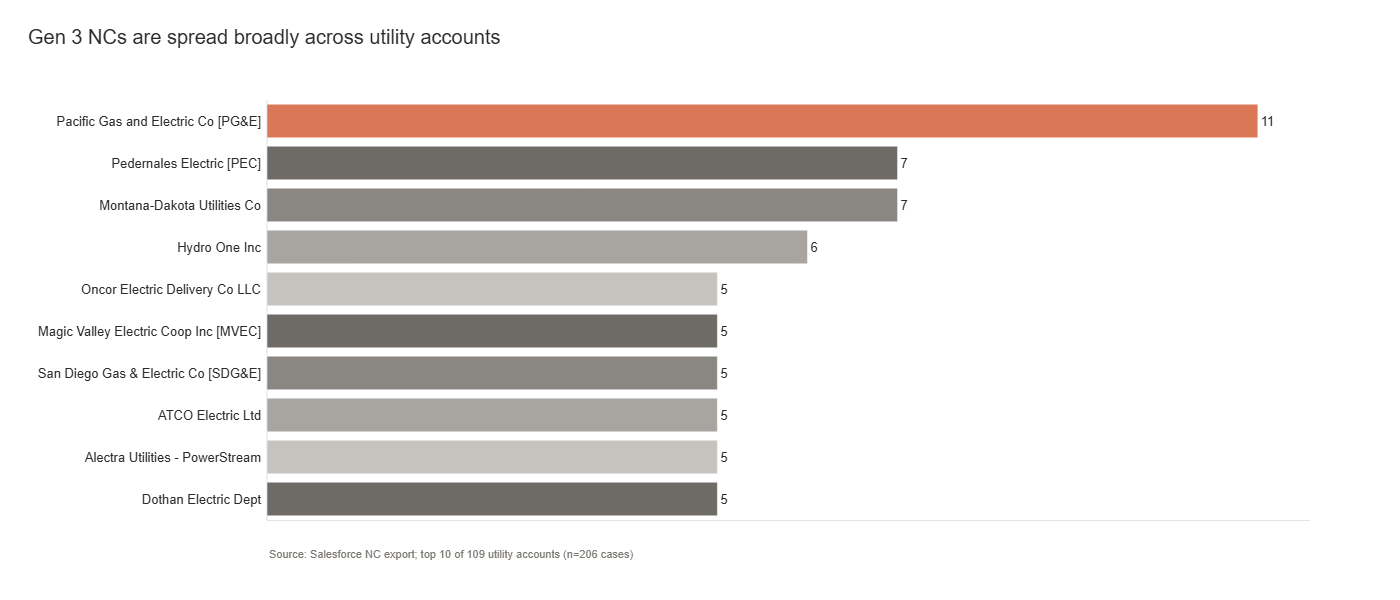

In [46]:
fig_utility_bar = ranked_bar(
    utility_top10, "Account Name", "Pacific Gas and Electric Co [PG&E]",
    "Gen 3 NCs are spread broadly across utility accounts",
)
add_source(
    fig_utility_bar,
    f"Source: Salesforce NC export; top 10 of {df_utility['Account Name'].nunique()} utility accounts (n={len(df_utility)} cases)",
)
fig_utility_bar.show()

In [47]:
print(tm_top10)

                                        Account Name  Count Label
0                                              ERMCO     17    17
1                                          Prolec GE      9     9
2                          Power Partners Inc. [PPI]      8     8
3                   Cam Tran [Spruce Grove Facility]      7     7
4  Hitachi Energy Canada (Formerly ABB, Inc. [Que...      7     7
5                 Emerald / Florida Transformer Inc.      4     4
6                 Cam Tran Pacific Ltd. (Chilliwack)      4     4
7                             Cam Tran Co. Ltd. (ON)      4     4
8                     Howard Industries - Laurel, MS      4     4
9                                   Fortune Electric      4     4


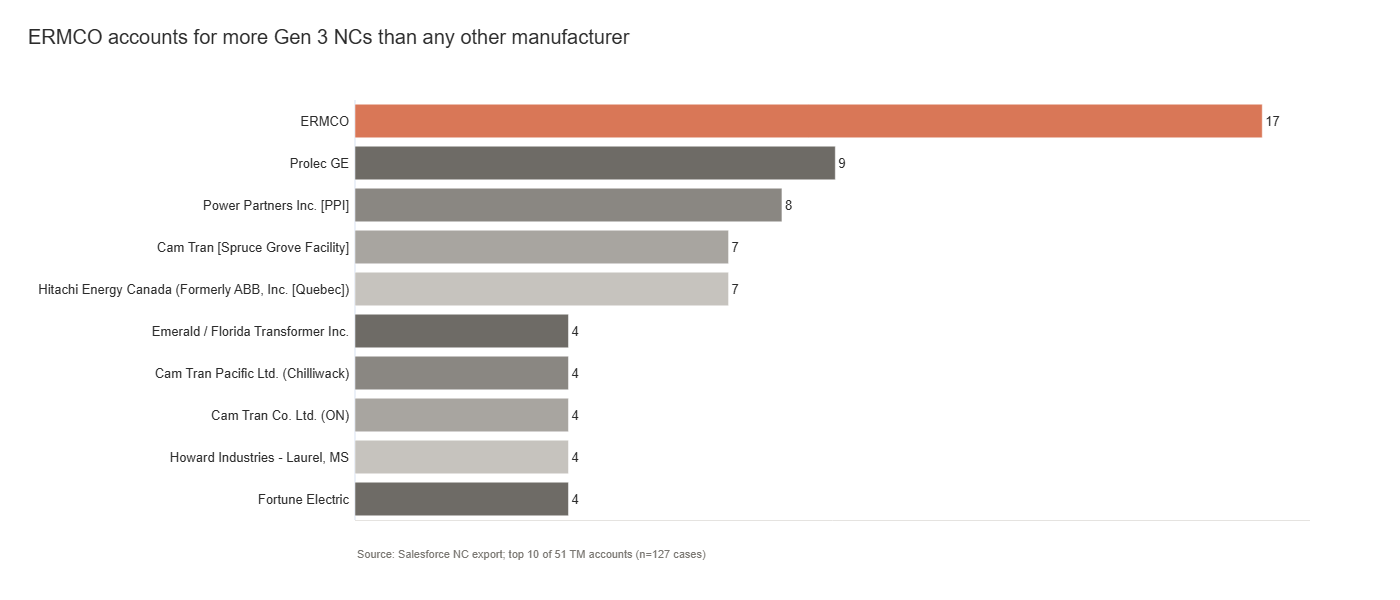

In [48]:
top_tm = tm_top10.iloc[0]["Account Name"]

fig_tm_bar = ranked_bar(
    tm_top10, "Account Name", top_tm,
    f"{top_tm} accounts for more Gen 3 NCs than any other manufacturer",
)
add_source(
    fig_tm_bar,
    f"Source: Salesforce NC export; top 10 of {df_tm['Account Name'].nunique()} TM accounts (n={len(df_tm)} cases)",
)
fig_tm_bar.show()

#### Investigate number of NC's Opened per Units Sold trend

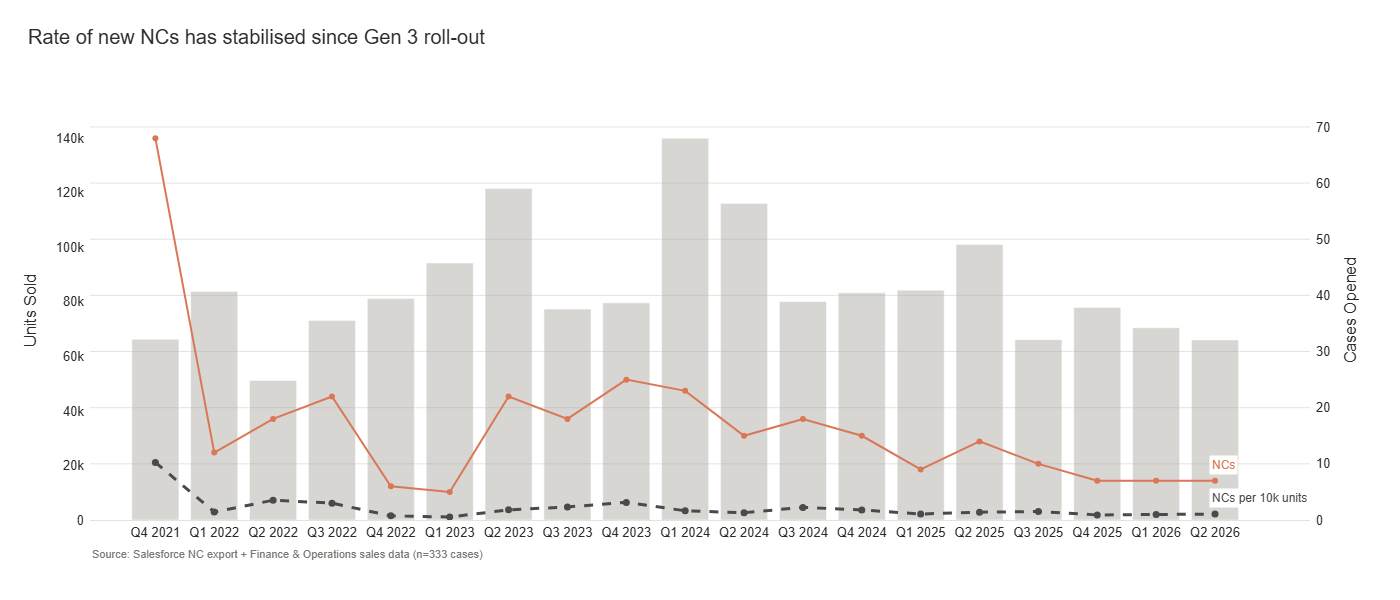

In [49]:
y2_max = max(combined['nc_count'].max(), combined['NC per 10k'].max()) * 1.1
last_q = combined['Quarter'].iloc[-1]

fig_units_vs_nc = go.Figure()

# Background context: units sold (bars, primary axis)
fig_units_vs_nc.add_trace(go.Bar(
    x=combined['Quarter'], y=combined['unit_sensors_sold'],
    name='Units Sold', yaxis='y1',
    marker=dict(color=CONTEXT, opacity=0.5),
))

# Raw NC count (secondary axis)
fig_units_vs_nc.add_trace(go.Scatter(
    x=combined['Quarter'], y=combined['nc_count'],
    name="NCs Opened", yaxis='y2',
    mode="lines+markers",
    line=dict(color=ACCENT, width=2),
    marker=dict(color=ACCENT, size=6),
))

# Headline normalized metric (secondary axis)
fig_units_vs_nc.add_trace(go.Scatter(
    x=combined['Quarter'], y=combined['NC per 10k'],
    name="NCs (Opened per 10k units sold)", yaxis='y2',
    mode="lines+markers",
    line=dict(color=NEUTRAL, width=3, dash="dash"),
    marker=dict(color=NEUTRAL, size=7),
))

fig_units_vs_nc.update_layout(
    title="Rate of new NCs has stabilised since Gen 3 roll-out",
    yaxis=dict(
        title="Units Sold",
        range=[0, combined['unit_sensors_sold'].max() * 1.1],
        showgrid=False,
    ),
    yaxis2=dict(
        title="Cases Opened",
        overlaying='y', side='right',
        range=[0, y2_max],
        gridcolor=GRID,
    ),
    xaxis=dict(title=""),
    showlegend=False,
)

fig_units_vs_nc.add_annotation(
    x=last_q, y=combined['nc_count'].iloc[-1], yref='y2',
    text="NCs",
    showarrow=False, xanchor='left', yanchor='bottom',
    xshift=-6, yshift=6,
    font=dict(color=ACCENT, size=12),
    bgcolor="white", borderpad=2,
)

fig_units_vs_nc.add_annotation(
    x=last_q, y=combined['NC per 10k'].iloc[-1], yref='y2',
    text="NCs per 10k units",
    showarrow=False, xanchor='left', yanchor='bottom',
    xshift=-6, yshift=6,
    font=dict(color=NEUTRAL, size=12),
    bgcolor="white", borderpad=2,
)

add_source(fig_units_vs_nc, f"Source: Salesforce NC export + Finance & Operations sales data (n={len(df_customer)} cases)")

fig_units_vs_nc.show()

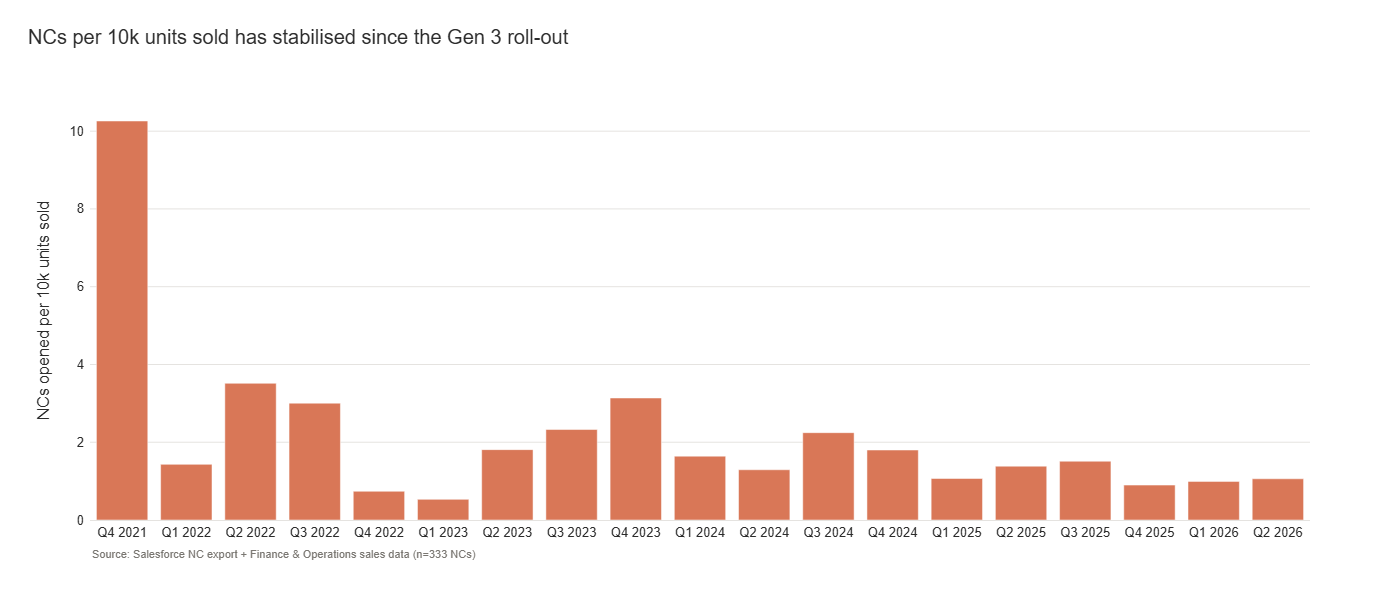

In [50]:
fig_nc_per_10k_bar = px.bar(
    combined,
    x="Quarter", y="NC per 10k",
    category_orders={"Quarter": quarter_order},
    title="NCs per 10k units sold has stabilised since the Gen 3 roll-out",   # verify against the data
)
fig_nc_per_10k_bar.update_traces(marker_color=ACCENT)
fig_nc_per_10k_bar.update_layout(
    xaxis=dict(title=""),
    yaxis=dict(title="NCs opened per 10k units sold"),
)
add_source(fig_nc_per_10k_bar, f"Source: Salesforce NC export + Finance & Operations sales data (n={len(df_customer)} NCs)")

#### Investigate problem flags and root cause trends over time

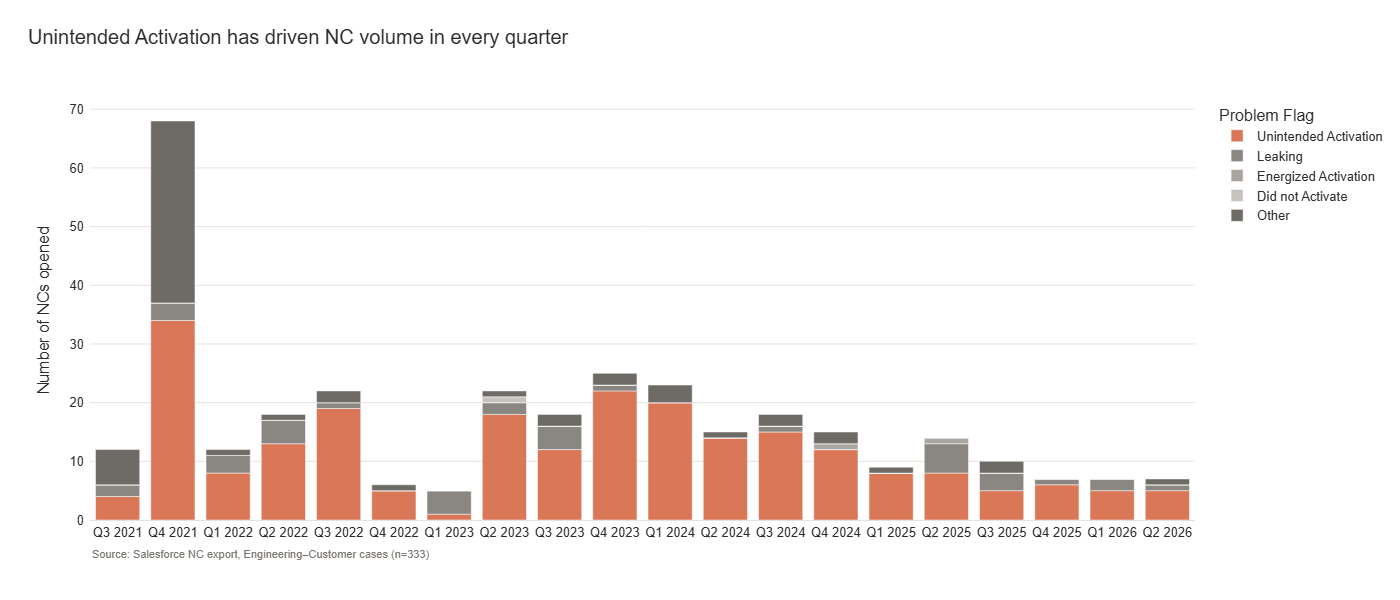

In [51]:
pflag_stack_order = ["Unintended Activation", "Leaking", "Energized Activation", "Did not Activate", "Other"]

fig_quarterly_pflag_bar = px.bar(
    quarterly_pflag_counts,
    x="Quarter", y="Count", color="Problem Flag",
    color_discrete_map=pflag_color_map,
    category_orders={
        "Quarter": quarter_order,
        "Problem Flag": pflag_stack_order,
    },
    title="Unintended Activation has driven NC volume in every quarter",
)
fig_quarterly_pflag_bar.update_layout(
    xaxis=dict(title=""),
    yaxis=dict(title="Number of NCs opened"),
)
add_source(fig_quarterly_pflag_bar, f"Source: Salesforce NC export, Engineering–Customer cases (n={len(df_customer)})")
fig_quarterly_pflag_bar.show()

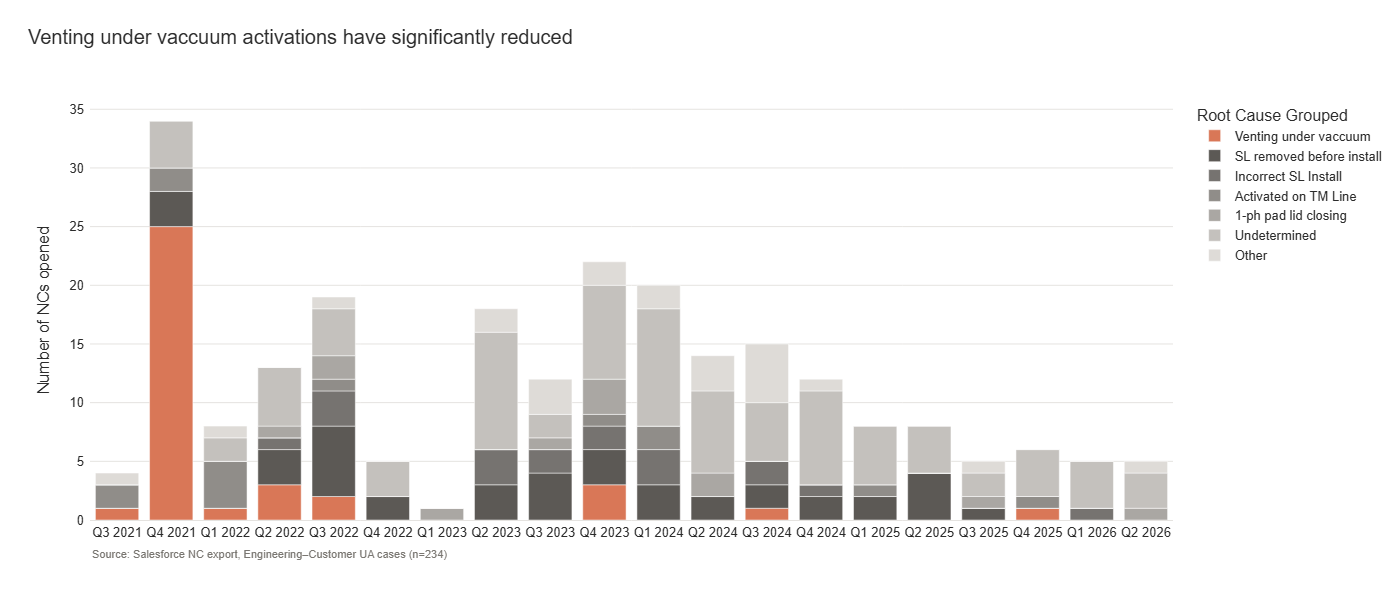

In [52]:
ua_stack_order = [
    "Venting under vaccuum",
    "SL removed before install",
    "Incorrect SL Install",
    "Activated on TM Line",
    "1-ph pad lid closing",
    "Undetermined",
    "Other",
]
ua_grouped_color_map = build_emphasis_map(ua_stack_order, "Venting under vaccuum", ramp=GREY_RAMP_LONG)

fig_quarterly_ua_grouped_bar = px.bar(
    quarterly_ua_grouped_counts,
    x="Quarter", y="Count", color="Root Cause Grouped",
    color_discrete_map=ua_grouped_color_map,
    category_orders={
        "Quarter": quarter_order,
        "Root Cause Grouped": ua_stack_order,
    },
    title="Venting under vaccuum activations have significantly reduced",
)
fig_quarterly_ua_grouped_bar.update_layout(
    xaxis=dict(title=""),
    yaxis=dict(title="Number of NCs opened"),
)
add_source(fig_quarterly_ua_grouped_bar, f"Source: Salesforce NC export, Engineering–Customer UA cases (n={len(df_ua)})")

Explore trends of each UA RC over time.

In [53]:
ua_rc_quarterly = build_quarterly_counts(df_ua, "Root Cause")
#future work to come here e.g. grid of ua rc's over time

### 5. Export
Save all charts as PNGs to /charts for the deck

In [55]:
charts_to_export = {
    "problem_flag_bar": fig_pflag_bar,
    "problem_flag_pie": fig_pflag_pie,
    "root_cause_all_bar": fig_rootcause_bar,
    "root_cause_known_bar": fig_rootcause_known_bar,
    "unintended_activation_root_cause_bar": fig_ua_bar,
    "unintended_activation_root_cause_pie_known": fig_ua_known_pie,
    "leaking_root_cause_bar": fig_leak_bar,
    "leaking_root_cause_pie": fig_leak_pie,
    "utility_top10_bar": fig_utility_bar,
    "tm_top10_bar": fig_tm_bar,
    "quarterly_pflag_bar" : fig_quarterly_pflag_bar,
    "quarterly_ua_bar": fig_quarterly_ua_grouped_bar,
    "nc_per_10k_bar": fig_nc_per_10k_bar,
    "units_vs_nc": fig_units_vs_nc,    
}

export_charts(charts_to_export, folder=FIGURES)